# Poisson Problem: THB-splines vs LR B-splines

This notebook solves the same Poisson problem with both methods and compares:
- mesh adaptivity strategies
- number of degrees of freedom
- sparsity patterns
- solution accuracy (L² and L∞ errors)
- h-refinement convergence

**Problem**: $-\Delta u = f$ on $\Omega = [0,1]^2$, $u = 0$ on $\partial\Omega$

**Exact solution**: $u^*(x,y) = \sin(\pi x)\sin(\pi y)$

**Right-hand side**: $f(x,y) = 2\pi^2\sin(\pi x)\sin(\pi y)$

In [11]:
import sys, pathlib
_root = pathlib.Path('..').resolve()   # project root, works wherever the notebook lives
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse.linalg as spla
import time

# ── THB-splines ──────────────────────────────────────────────────────────────
from THBSplines.src.hierarchical_space import HierarchicalSpace
from THBSplines.src.refinement import refine as thb_refine
from THBSplines.src.assembly import hierarchical_stiffness_matrix, hierarchical_mass_matrix
from THBSplines.src.evaluation import evaluate_hierarchical_basis

# ── LR B-splines ─────────────────────────────────────────────────────────────
from LRSplines.src.lr_spline_space import LRSplineSpace
from LRSplines.src.lr_mesh import MeshLine
from LRSplines.src.refinement import refine as lr_refine, refine_region
from LRSplines.src.assembly import lr_stiffness_matrix, lr_load_vector


# ── HB-splines (1-D) ──────────────────────────────────────────────────────────
from HBSplines.src.hb_space  import HBsplineSpace
from HBSplines.src.assembly  import hb_stiffness_matrix, hb_load_vector_full, hb_solve
from HBSplines               import adaptive_solve, AdaptiveSolverSettings
from HBSplines.problems      import smooth_diffusion, boundary_layer_right

%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
    'axes.facecolor': '#fbfbf8',
    'axes.edgecolor': '#262626',
    'axes.linewidth': 0.9,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.color': '#d9d4cb',
    'grid.linewidth': 0.7,
    'grid.alpha': 0.45,
    'grid.linestyle': '--',
    'font.size': 11,
    'font.family': 'STIXGeneral',
    'mathtext.fontset': 'stix',
    'legend.frameon': False,
    'legend.fontsize': 9,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# Shared colour constants (same as individual tutorials)
LINE_COLORS  = ['#0f4c5c', '#e36414', '#6a994e', '#7b2cbf', '#c1121f', '#1d3557']
SURFACE_CMAP = 'viridis'
ERROR_CMAP   = 'magma'


def style_axes(ax, *, square=False, xlabel=None, ylabel=None, title=None):
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    if title  is not None: ax.set_title(title, pad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if square: ax.set_aspect('equal', adjustable='box')
    return ax


def contour_panel(fig, ax, X, Y, Z, *, levels=18, cmap=SURFACE_CMAP,
                  xlabel='$x$', ylabel='$y$', title=None, square=True,
                  colorbar_label=None, vmin=None, vmax=None):
    cf = ax.contourf(X, Y, Z, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    style_axes(ax, square=square, xlabel=xlabel, ylabel=ylabel, title=title)
    cbar = fig.colorbar(cf, ax=ax, pad=0.02, fraction=0.048)
    if colorbar_label is not None: cbar.set_label(colorbar_label)
    return cf, cbar


# ── Shared problem data ───────────────────────────────────────────────────────
def u_exact(pts):
    return np.sin(np.pi * pts[:, 0]) * np.sin(np.pi * pts[:, 1])

def f_rhs(pts):
    return 2 * np.pi**2 * np.sin(np.pi * pts[:, 0]) * np.sin(np.pi * pts[:, 1])

# Evaluation grid used throughout the notebook
N_PLOT = 80
xg = np.linspace(0.005, 0.995, N_PLOT)
XG, YG = np.meshgrid(xg, xg)
PTS_PLOT    = np.column_stack([XG.ravel(), YG.ravel()])
U_EX_GRID   = u_exact(PTS_PLOT).reshape(N_PLOT, N_PLOT)

print('Setup complete.')

Setup complete.


---
## 1. Single-level comparison

Both spaces start from the same coarse biquadratic mesh on $[0,1]^2$ with knots
$\{0, 0.25, 0.5, 0.75, 1\}$, then refine the central region $[0.25, 0.75]^2$ once.

| Method | Refinement strategy |
|--------|--------------------|
| THB-splines | Hierarchical: deactivate coarse functions, add fine level |
| LR B-splines | Overloading: split only the functions overloaded by each new mesh line |

In [12]:
# ── THB: build space and refine ──────────────────────────────────────────────
knots0 = [[0, 0, 0, 0.25, 0.5, 0.75, 1, 1, 1],
           [0, 0, 0, 0.25, 0.5, 0.75, 1, 1, 1]]
Tp = HierarchicalSpace(knots0, [2, 2], dim=2)
rect = np.array([[0.25, 0.75], [0.25, 0.75]])
cells_l0 = Tp.refine_in_rectangle(rect, level=0)
Tp = thb_refine(Tp, {0: cells_l0})
print(f'THB-splines: {Tp.nfuncs} DOFs  ({Tp.nlevels} levels)')

# ── LR: build space and refine ───────────────────────────────────────────────
Lp = LRSplineSpace(
    knots_u=[0, 0, 0, 0.25, 0.5, 0.75, 1, 1, 1],
    knots_v=[0, 0, 0, 0.25, 0.5, 0.75, 1, 1, 1],
    degree_u=2, degree_v=2)
refine_region(Lp, 0.25, 0.75, 0.25, 0.75, n_lines_u=2, n_lines_v=2)
print(f'LR B-splines: {Lp.nfuncs} DOFs  ({Lp.mesh.nelements} elements)')

print(f'\nPartition of unity — LR: {Lp.check_partition_of_unity()}')

THB-splines: 40 DOFs  (2 levels)
LR B-splines: 36 DOFs  (28 elements)

Partition of unity — LR: True


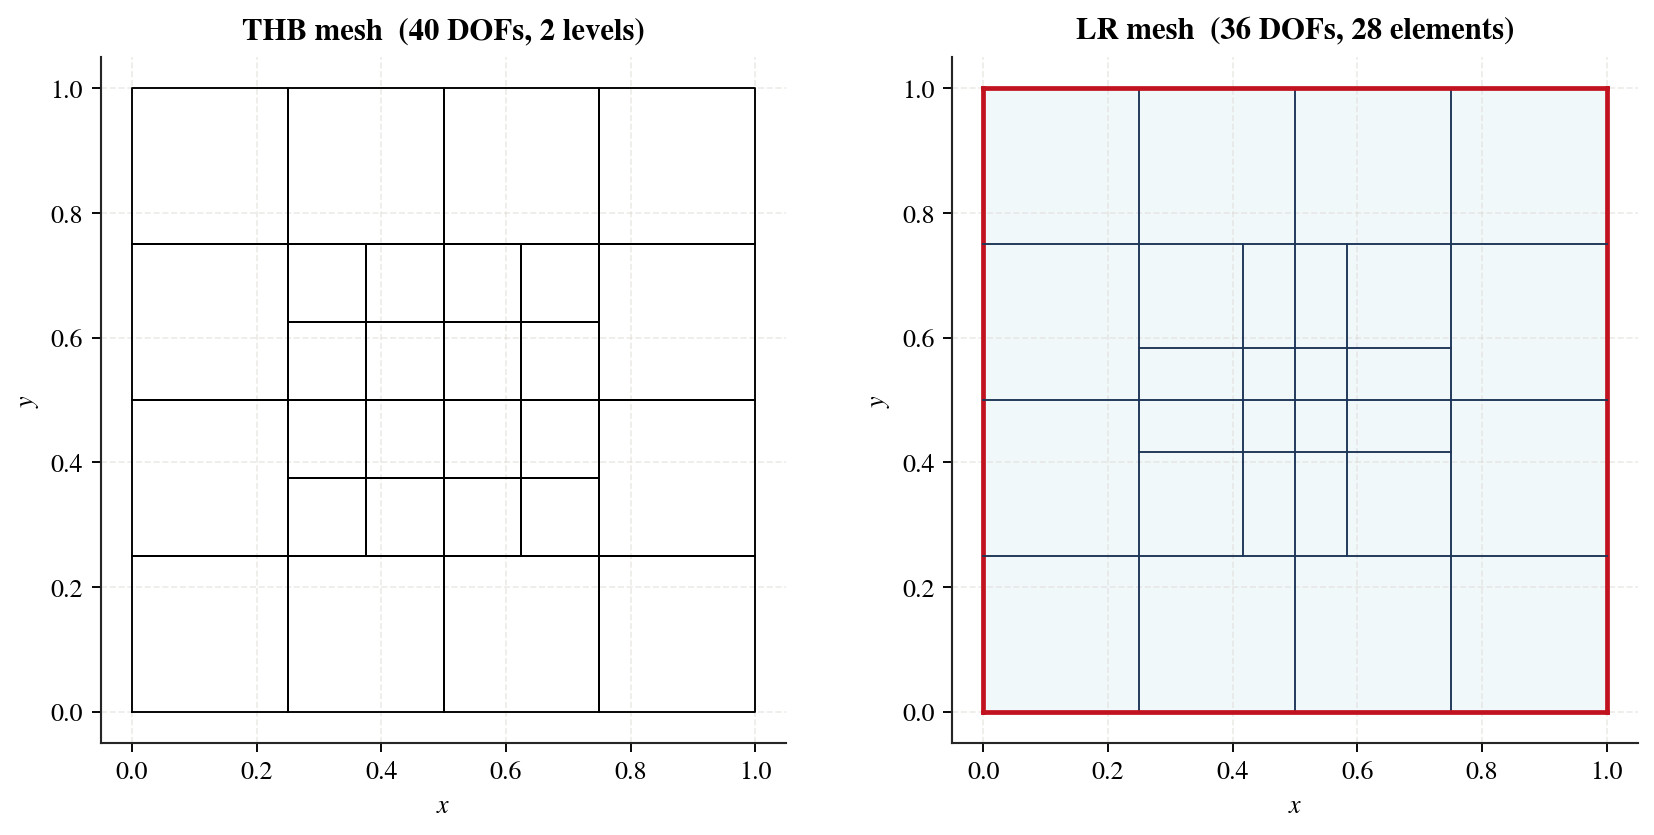

In [13]:
# ── Visualise the two adaptive meshes side-by-side ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), constrained_layout=True)

# return_fig=True suppresses the plt.show() call inside plot_cells,
# which would otherwise flush a partial figure before the LR mesh is drawn.
Tp.mesh.plot_cells(ax=axes[0], return_fig=True)
style_axes(axes[0], square=True, xlabel='$x$', ylabel='$y$',
           title=f'THB mesh  ({Tp.nfuncs} DOFs, {Tp.nlevels} levels)')
axes[0].set_facecolor('white')

Lp.mesh.plot(ax=axes[1])
style_axes(axes[1], square=True, xlabel='$x$', ylabel='$y$',
           title=f'LR mesh  ({Lp.nfuncs} DOFs, {Lp.mesh.nelements} elements)')
axes[1].set_facecolor('white')

---
## 2. Assemble and solve

We assemble the stiffness matrix $A$ and load vector $\mathbf{f}$ for both methods,
then apply homogeneous Dirichlet BCs and solve $A\mathbf{c} = \mathbf{f}$.

In [14]:
# ── THB: assemble stiffness matrix and load vector ───────────────────────────

def _thb_load_vector(T, f, order=5):
    """Element-wise Gauss-quadrature load vector for a HierarchicalSpace."""
    pts_1d, w_1d = np.polynomial.legendre.leggauss(order)
    fv = np.zeros(T.nfuncs)
    for lev in range(T.nlevels):
        cells = T.mesh.meshes[lev].cells[T.mesh.aelem_level[lev]]
        for cell in cells:
            u0, u1 = cell[0, 0], cell[0, 1]
            v0, v1 = cell[1, 0], cell[1, 1]
            up = 0.5*(u1-u0)*pts_1d + 0.5*(u0+u1)
            vp = 0.5*(v1-v0)*pts_1d + 0.5*(v0+v1)
            U, V = np.meshgrid(up, vp)
            pts = np.column_stack([U.ravel(), V.ravel()])
            Wu, Wv = np.meshgrid(w_1d, w_1d)
            w = (Wu * Wv).ravel() * 0.25*(u1-u0)*(v1-v0)
            B = evaluate_hierarchical_basis(T, pts)
            fv += B.T @ (w * f(pts))
    return fv


t0 = time.perf_counter()
A_thb = hierarchical_stiffness_matrix(Tp)
f_thb = _thb_load_vector(Tp, f_rhs, order=5)
t_asm_thb = time.perf_counter() - t0

# ── Dirichlet BCs via Greville abscissae ─────────────────────────────────────
eps = 1e-12
is_interior_thb = np.zeros(Tp.nfuncs, dtype=bool)
cumul = 0
for lev in range(Tp.nlevels):
    sp   = Tp.spaces[lev]
    kx, ky = sp.knots[0], sp.knots[1]
    p    = sp.degrees[0]
    nx, ny = sp.nfuncs_onedim
    gx = np.array([np.mean(kx[i + 1:i + p + 1]) for i in range(nx)])
    gy = np.array([np.mean(ky[j + 1:j + p + 1]) for j in range(ny)])
    active = Tp.afunc_level[lev]
    n_lev  = Tp.nfuncs_level[lev]
    for local_idx, k in enumerate(active):
        i, j = k // ny, k % ny
        if gx[i] > eps and gx[i] < 1 - eps and gy[j] > eps and gy[j] < 1 - eps:
            is_interior_thb[cumul + local_idx] = True
    cumul += n_lev

idx_thb   = np.where(is_interior_thb)[0]
A_int_thb = A_thb.tocsr()[np.ix_(idx_thb, idx_thb)]
f_int_thb = f_thb[idx_thb]

t0 = time.perf_counter()
c_int_thb = spla.spsolve(A_int_thb, f_int_thb)
t_solve_thb = time.perf_counter() - t0

c_thb = np.zeros(Tp.nfuncs)
c_thb[idx_thb] = c_int_thb

print(f'THB: {Tp.nfuncs} DOFs  ({len(idx_thb)} interior)')
print(f'  Assembly : {t_asm_thb:.3f} s')
print(f'  Solve    : {t_solve_thb:.4f} s')

Stiffness matrix  level=1: 100%|██████████| 16/16 [00:00<00:00, 71.20it/s]


THB: 40 DOFs  (20 interior)
  Assembly : 0.829 s
  Solve    : 0.0002 s


In [15]:
# ── LR: assemble ─────────────────────────────────────────────────────────────
t0 = time.perf_counter()
A_lr = lr_stiffness_matrix(Lp, gauss_order=5)
f_lr = lr_load_vector(Lp, f_rhs, gauss_order=5)
t_asm_lr = time.perf_counter() - t0

# Dirichlet BC via Greville abscissae
grev = Lp.greville_points
on_bnd_lr = ((grev[:, 0] < eps) | (grev[:, 0] > 1 - eps) |
             (grev[:, 1] < eps) | (grev[:, 1] > 1 - eps))
idx_lr = np.where(~on_bnd_lr)[0]

A_int_lr = A_lr.tocsr()[np.ix_(idx_lr, idx_lr)]
f_int_lr = f_lr[idx_lr]

t0 = time.perf_counter()
c_int_lr = spla.spsolve(A_int_lr, f_int_lr)
t_solve_lr = time.perf_counter() - t0

c_lr = np.zeros(Lp.nfuncs)
c_lr[idx_lr] = c_int_lr

print(f'LR: {Lp.nfuncs} DOFs  ({len(idx_lr)} interior)')
print(f'  Assembly : {t_asm_lr:.3f} s')
print(f'  Solve    : {t_solve_lr:.4f} s')

LR: 36 DOFs  (16 interior)
  Assembly : 0.371 s
  Solve    : 0.0003 s


---
## 3. Solutions and errors

In [16]:
# ── Evaluate both solutions on the plot grid ─────────────────────────────────
B_thb_plot = evaluate_hierarchical_basis(Tp, PTS_PLOT)   # (N², nfuncs)
u_thb = (B_thb_plot @ c_thb).reshape(N_PLOT, N_PLOT)

B_lr_plot = Lp.evaluate(PTS_PLOT)                        # (N², nfuncs)
u_lr  = (B_lr_plot * c_lr).sum(axis=1).reshape(N_PLOT, N_PLOT)

err_thb = np.abs(u_thb - U_EX_GRID)
err_lr  = np.abs(u_lr  - U_EX_GRID)

L2_thb  = np.sqrt(np.mean((u_thb - U_EX_GRID)**2))
Linf_thb = err_thb.max()
L2_lr   = np.sqrt(np.mean((u_lr  - U_EX_GRID)**2))
Linf_lr  = err_lr.max()

print(f'          {"THB-splines":>16}   {"LR B-splines":>16}')
print(f'DOFs      {Tp.nfuncs:>16}   {Lp.nfuncs:>16}')
print(f'L² error  {L2_thb:>16.4e}   {L2_lr:>16.4e}')
print(f'L∞ error  {Linf_thb:>16.4e}   {Linf_lr:>16.4e}')

               THB-splines       LR B-splines
DOFs                    40                 36
L² error        2.3107e-03         2.3075e-03
L∞ error        5.2775e-03         5.0402e-03


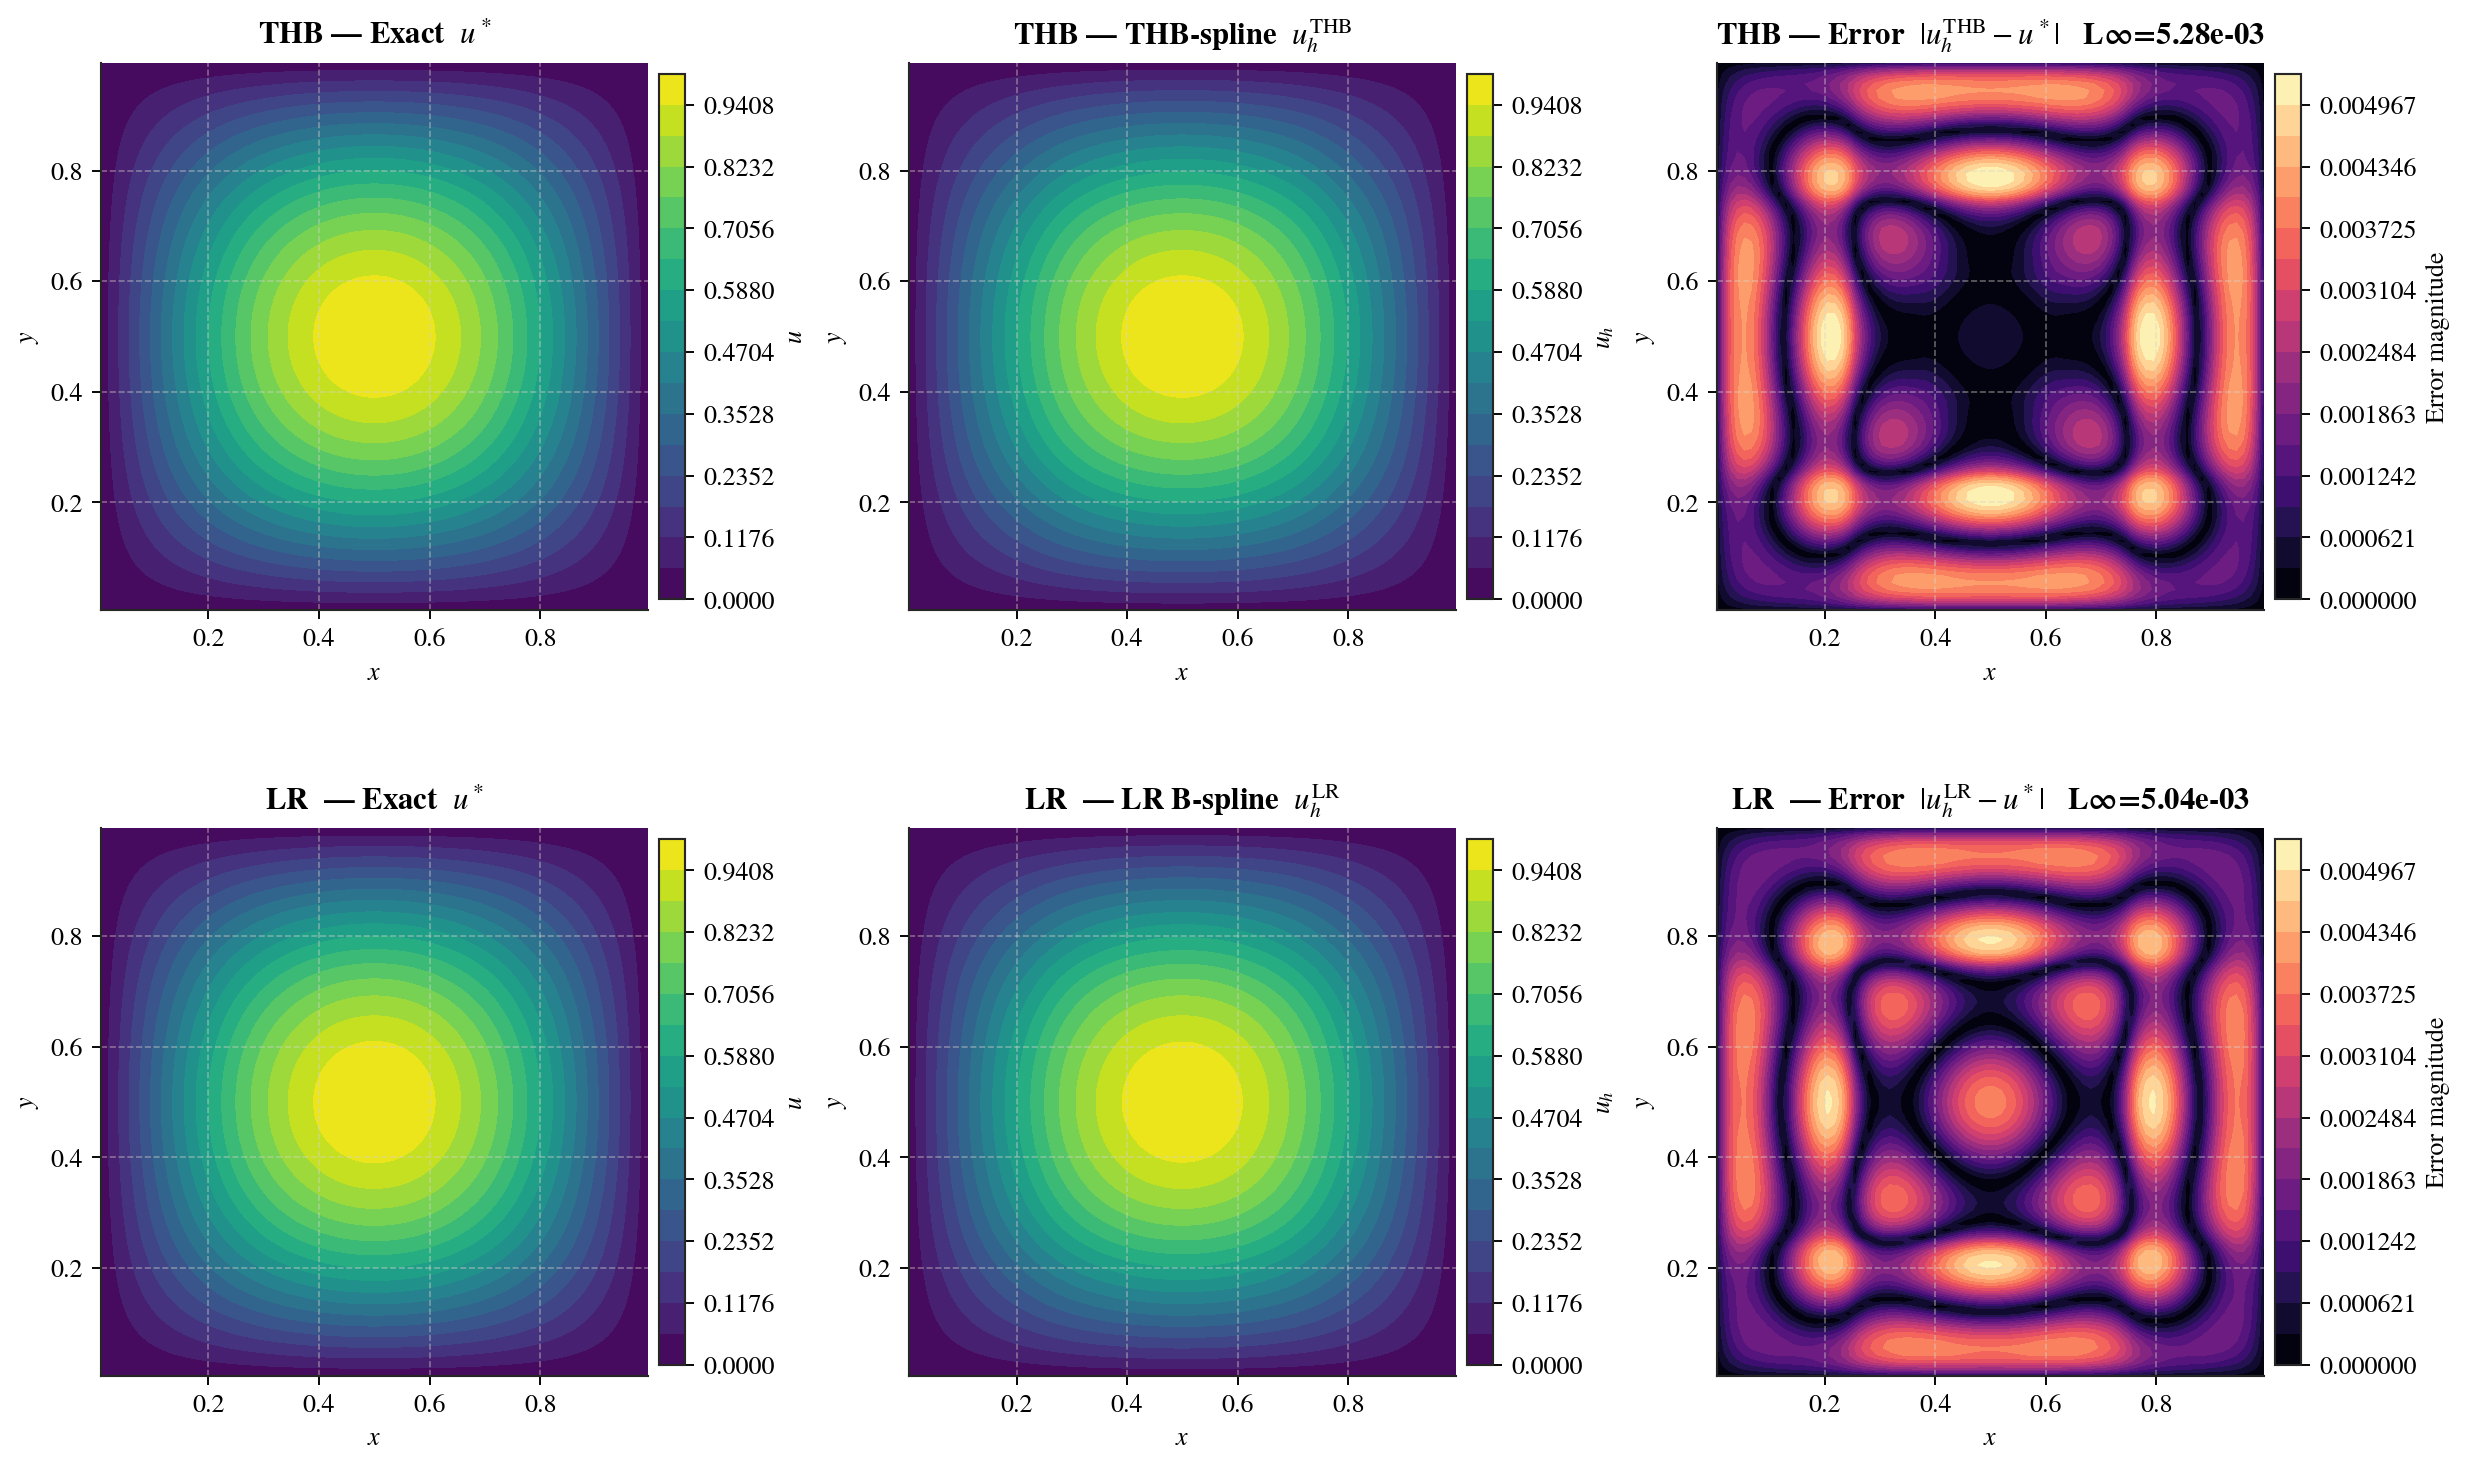

In [17]:
# ── Side-by-side solution plots ──────────────────────────────────────────────
sol_levels = np.linspace(0.0, max(u_thb.max(), u_lr.max(), U_EX_GRID.max()), 18)
err_levels = np.linspace(0.0, max(err_thb.max(), err_lr.max()), 18)

fig, axes = plt.subplots(2, 3, figsize=(14.4, 9.0), constrained_layout=True)

# Top row: THB-splines
contour_panel(fig, axes[0, 0], XG, YG, U_EX_GRID, levels=sol_levels, cmap=SURFACE_CMAP,
              title=r'Exact  $u^*$', colorbar_label='$u$')
contour_panel(fig, axes[0, 1], XG, YG, u_thb, levels=sol_levels, cmap=SURFACE_CMAP,
              title=r'THB-spline  $u_h^{\rm THB}$', colorbar_label='$u_h$')
contour_panel(fig, axes[0, 2], XG, YG, err_thb, levels=err_levels, cmap=ERROR_CMAP,
              title=fr'Error  $|u_h^{{\rm THB}}-u^*|$   L∞={Linf_thb:.2e}',
              colorbar_label='Error magnitude')

# Bottom row: LR B-splines
contour_panel(fig, axes[1, 0], XG, YG, U_EX_GRID, levels=sol_levels, cmap=SURFACE_CMAP,
              title=r'Exact  $u^*$', colorbar_label='$u$')
contour_panel(fig, axes[1, 1], XG, YG, u_lr, levels=sol_levels, cmap=SURFACE_CMAP,
              title=r'LR B-spline  $u_h^{\rm LR}$', colorbar_label='$u_h$')
contour_panel(fig, axes[1, 2], XG, YG, err_lr, levels=err_levels, cmap=ERROR_CMAP,
              title=fr'Error  $|u_h^{{\rm LR}}-u^*|$   L∞={Linf_lr:.2e}',
              colorbar_label='Error magnitude')

for ax in axes[0]:
    ax.set_title('THB — ' + ax.get_title(), pad=8)
for ax in axes[1]:
    ax.set_title('LR  — ' + ax.get_title(), pad=8)

---
## 4. Stiffness matrix comparison

Text(0.5, 1.01, 'Stiffness matrix sparsity patterns')

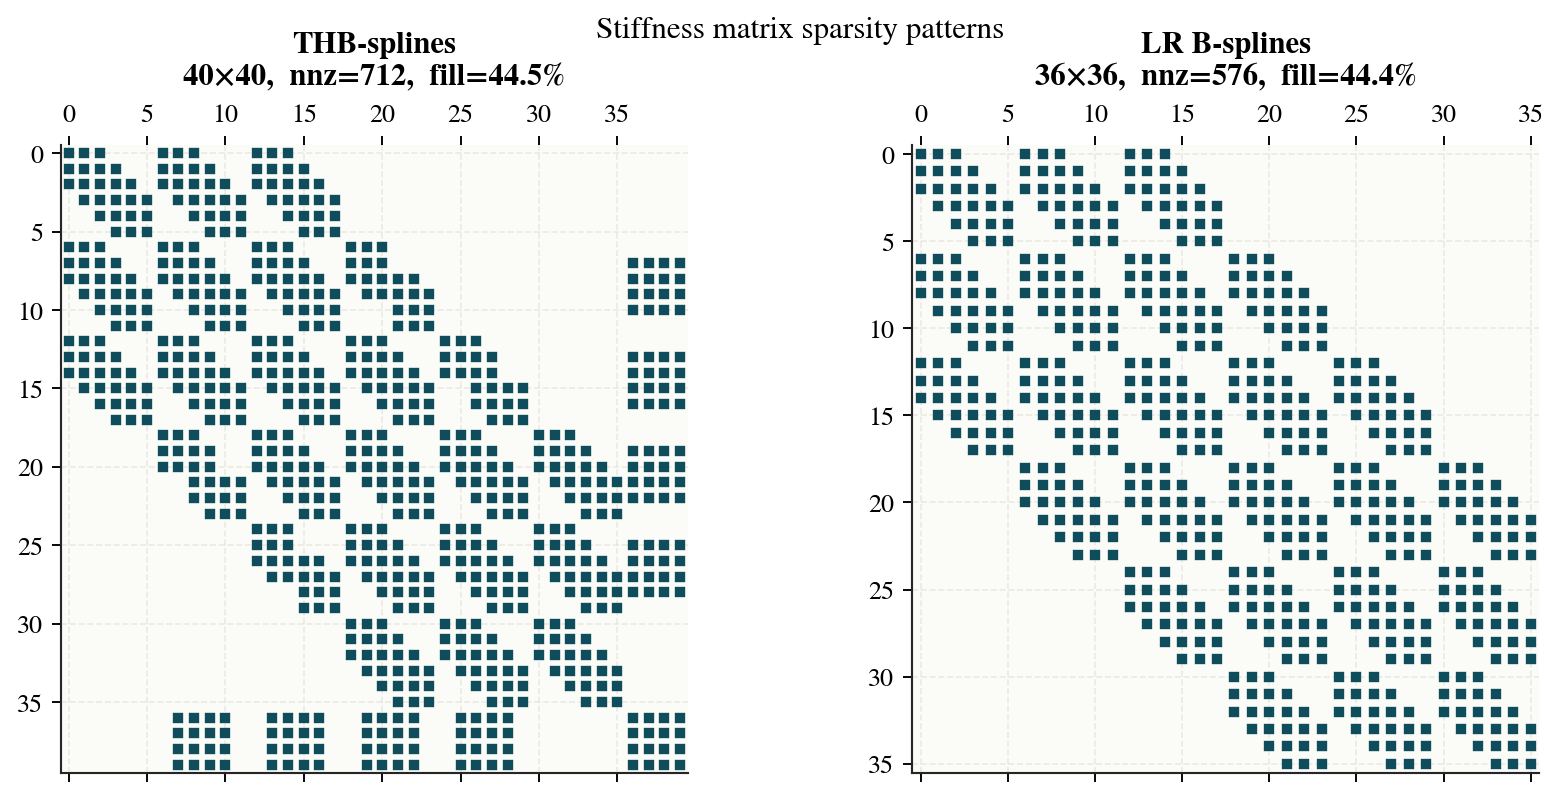

In [18]:
# ── Stiffness matrix sparsity patterns ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

for ax, mat, label, ndofs in [
        (axes[0], A_thb, 'THB-splines', Tp.nfuncs),
        (axes[1], A_lr,  'LR B-splines', Lp.nfuncs)]:
    ax.spy(mat, markersize=3, color=LINE_COLORS[0])
    density = mat.nnz / ndofs**2 * 100
    style_axes(ax, title=f'{label}\n{ndofs}×{ndofs},  nnz={mat.nnz},  fill={density:.1f}%')

fig.suptitle('Stiffness matrix sparsity patterns', y=1.01)

In [19]:
# ── Summary table ────────────────────────────────────────────────────────────
rows = [
    ('Method',         'THB-splines',             'LR B-splines'),
    ('DOFs',           str(Tp.nfuncs),             str(Lp.nfuncs)),
    ('Interior DOFs',  str(len(idx_thb)),          str(len(idx_lr))),
    ('Stiffness nnz',  str(A_thb.nnz),             str(A_lr.nnz)),
    ('Assembly (s)',   f'{t_asm_thb:.3f}',         f'{t_asm_lr:.3f}'),
    ('Solve (s)',      f'{t_solve_thb:.4f}',       f'{t_solve_lr:.4f}'),
    ('L² error',       f'{L2_thb:.3e}',            f'{L2_lr:.3e}'),
    ('L∞ error',       f'{Linf_thb:.3e}',          f'{Linf_lr:.3e}'),
]

col_w = [max(len(r[c]) for r in rows) for c in range(3)]
sep   = '+' + '+'.join('-' * (w + 2) for w in col_w) + '+'
print(sep)
for i, row in enumerate(rows):
    line = '| ' + ' | '.join(cell.ljust(col_w[c]) for c, cell in enumerate(row)) + ' |'
    print(line)
    if i == 0:
        print(sep)
print(sep)

+---------------+-------------+--------------+
| Method        | THB-splines | LR B-splines |
+---------------+-------------+--------------+
| DOFs          | 40          | 36           |
| Interior DOFs | 20          | 16           |
| Stiffness nnz | 712         | 576          |
| Assembly (s)  | 0.829       | 0.371        |
| Solve (s)     | 0.0002      | 0.0003       |
| L² error      | 2.311e-03   | 2.307e-03    |
| L∞ error      | 5.277e-03   | 5.040e-03    |
+---------------+-------------+--------------+


---
## 5. Convergence study

We uniformly refine both spaces by repeatedly halving the mesh spacing and measure
the L² and L∞ errors.  For biquadratic ($p=2$) splines on a quasi-uniform mesh we
expect **optimal** rates:

$$\|u - u_h\|_{L^2} = O(h^3), \qquad \|u - u_h\|_{L^\infty} = O(h^3)$$

In [20]:
def _thb_greville_interior(T):
    """Return the indices of interior THB DOFs using Greville abscissae."""
    eps = 1e-12
    is_int = np.zeros(T.nfuncs, dtype=bool)
    cumul = 0
    for lev in range(T.nlevels):
        sp   = T.spaces[lev]
        kx, ky = sp.knots[0], sp.knots[1]
        p    = sp.degrees[0]
        nx, ny = sp.nfuncs_onedim
        gx = np.array([np.mean(kx[i + 1:i + p + 1]) for i in range(nx)])
        gy = np.array([np.mean(ky[j + 1:j + p + 1]) for j in range(ny)])
        active = T.afunc_level[lev]
        n_lev  = T.nfuncs_level[lev]
        for local_idx, k in enumerate(active):
            i, j = k // ny, k % ny
            if gx[i] > eps and gx[i] < 1 - eps and gy[j] > eps and gy[j] < 1 - eps:
                is_int[cumul + local_idx] = True
        cumul += n_lev
    return np.where(is_int)[0]


def _thb_load_vector_gauss(T, f, order=5):
    """Element-wise Gauss load vector (reusable in convergence loop)."""
    pts_1d, w_1d = np.polynomial.legendre.leggauss(order)
    fv = np.zeros(T.nfuncs)
    for lev in range(T.nlevels):
        cells = T.mesh.meshes[lev].cells[T.mesh.aelem_level[lev]]
        for cell in cells:
            u0, u1 = cell[0, 0], cell[0, 1]
            v0, v1 = cell[1, 0], cell[1, 1]
            up = 0.5*(u1-u0)*pts_1d + 0.5*(u0+u1)
            vp = 0.5*(v1-v0)*pts_1d + 0.5*(v0+v1)
            U, V = np.meshgrid(up, vp)
            pts = np.column_stack([U.ravel(), V.ravel()])
            Wu, Wv = np.meshgrid(w_1d, w_1d)
            w = (Wu * Wv).ravel() * 0.25*(u1-u0)*(v1-v0)
            B = evaluate_hierarchical_basis(T, pts)
            fv += B.T @ (w * f(pts))
    return fv


def solve_thb(n_interior):
    """Uniform THB space, n_interior interior knot spans per direction."""
    h = 1.0 / (n_interior + 1)
    knots = [0., 0., 0.] + list(np.linspace(h, 1 - h, n_interior)) + [1., 1., 1.]
    T = HierarchicalSpace([knots, knots], [2, 2], dim=2)

    A     = hierarchical_stiffness_matrix(T)
    f_vec = _thb_load_vector_gauss(T, f_rhs, order=5)

    idx = _thb_greville_interior(T)
    c_int = spla.spsolve(A.tocsr()[np.ix_(idx, idx)], f_vec[idx])
    c = np.zeros(T.nfuncs);  c[idx] = c_int

    B_plot = evaluate_hierarchical_basis(T, PTS_PLOT)
    u_h   = (B_plot @ c).reshape(N_PLOT, N_PLOT)
    L2    = np.sqrt(np.mean((u_h - U_EX_GRID)**2))
    Linf  = np.abs(u_h - U_EX_GRID).max()
    return T.nfuncs, h, L2, Linf


def solve_lr(n_interior):
    """Uniform LR space, n_interior interior knot spans per direction."""
    h = 1.0 / (n_interior + 1)
    knots = [0., 0., 0.] + list(np.linspace(h, 1 - h, n_interior)) + [1., 1., 1.]
    L = LRSplineSpace(knots_u=knots, knots_v=knots, degree_u=2, degree_v=2)

    A = lr_stiffness_matrix(L, gauss_order=4)
    f = lr_load_vector(L, f_rhs, gauss_order=4)

    eps  = 1e-12
    grev = L.greville_points
    on_bnd = ((grev[:, 0] < eps) | (grev[:, 0] > 1 - eps) |
              (grev[:, 1] < eps) | (grev[:, 1] > 1 - eps))
    idx = np.where(~on_bnd)[0]
    c_int = spla.spsolve(A.tocsr()[np.ix_(idx, idx)], f[idx])
    c = np.zeros(L.nfuncs);  c[idx] = c_int

    B_plot = L.evaluate(PTS_PLOT)
    u_h   = (B_plot * c).sum(axis=1).reshape(N_PLOT, N_PLOT)
    L2    = np.sqrt(np.mean((u_h - U_EX_GRID)**2))
    Linf  = np.abs(u_h - U_EX_GRID).max()
    return L.nfuncs, h, L2, Linf


print('Running convergence study (uniform refinement)...')
levels = [1, 2, 3, 4, 5]

results_thb = [solve_thb(n) for n in levels]
results_lr  = [solve_lr(n)  for n in levels]

print('Done.')
print(f'\n{"n":>4}  {"THB DOFs":>9}  {"THB L2":>10}  {"LR DOFs":>9}  {"LR L2":>10}')
for n, (nd_t, h_t, l2_t, _), (nd_l, h_l, l2_l, _) in zip(levels, results_thb, results_lr):
    print(f'{n:>4}  {nd_t:>9}  {l2_t:>10.3e}  {nd_l:>9}  {l2_l:>10.3e}')

Running convergence study (uniform refinement)...


Stiffness matrix  level=0: 100%|██████████| 36/36 [00:00<00:00, 73.71it/s]


Done.

   n   THB DOFs      THB L2    LR DOFs       LR L2
   1         16   2.758e-02         16   2.758e-02
   2         25   6.128e-03         25   6.128e-03
   3         36   2.307e-03         36   2.307e-03
   4         49   1.117e-03         49   1.117e-03
   5         64   6.267e-04         64   6.267e-04


Empirical L²  rate — THB: 3.44   LR: 3.44
Empirical L∞  rate — THB: 3.68   LR: 3.68
Expected: ~3.0 for biquadratic splines


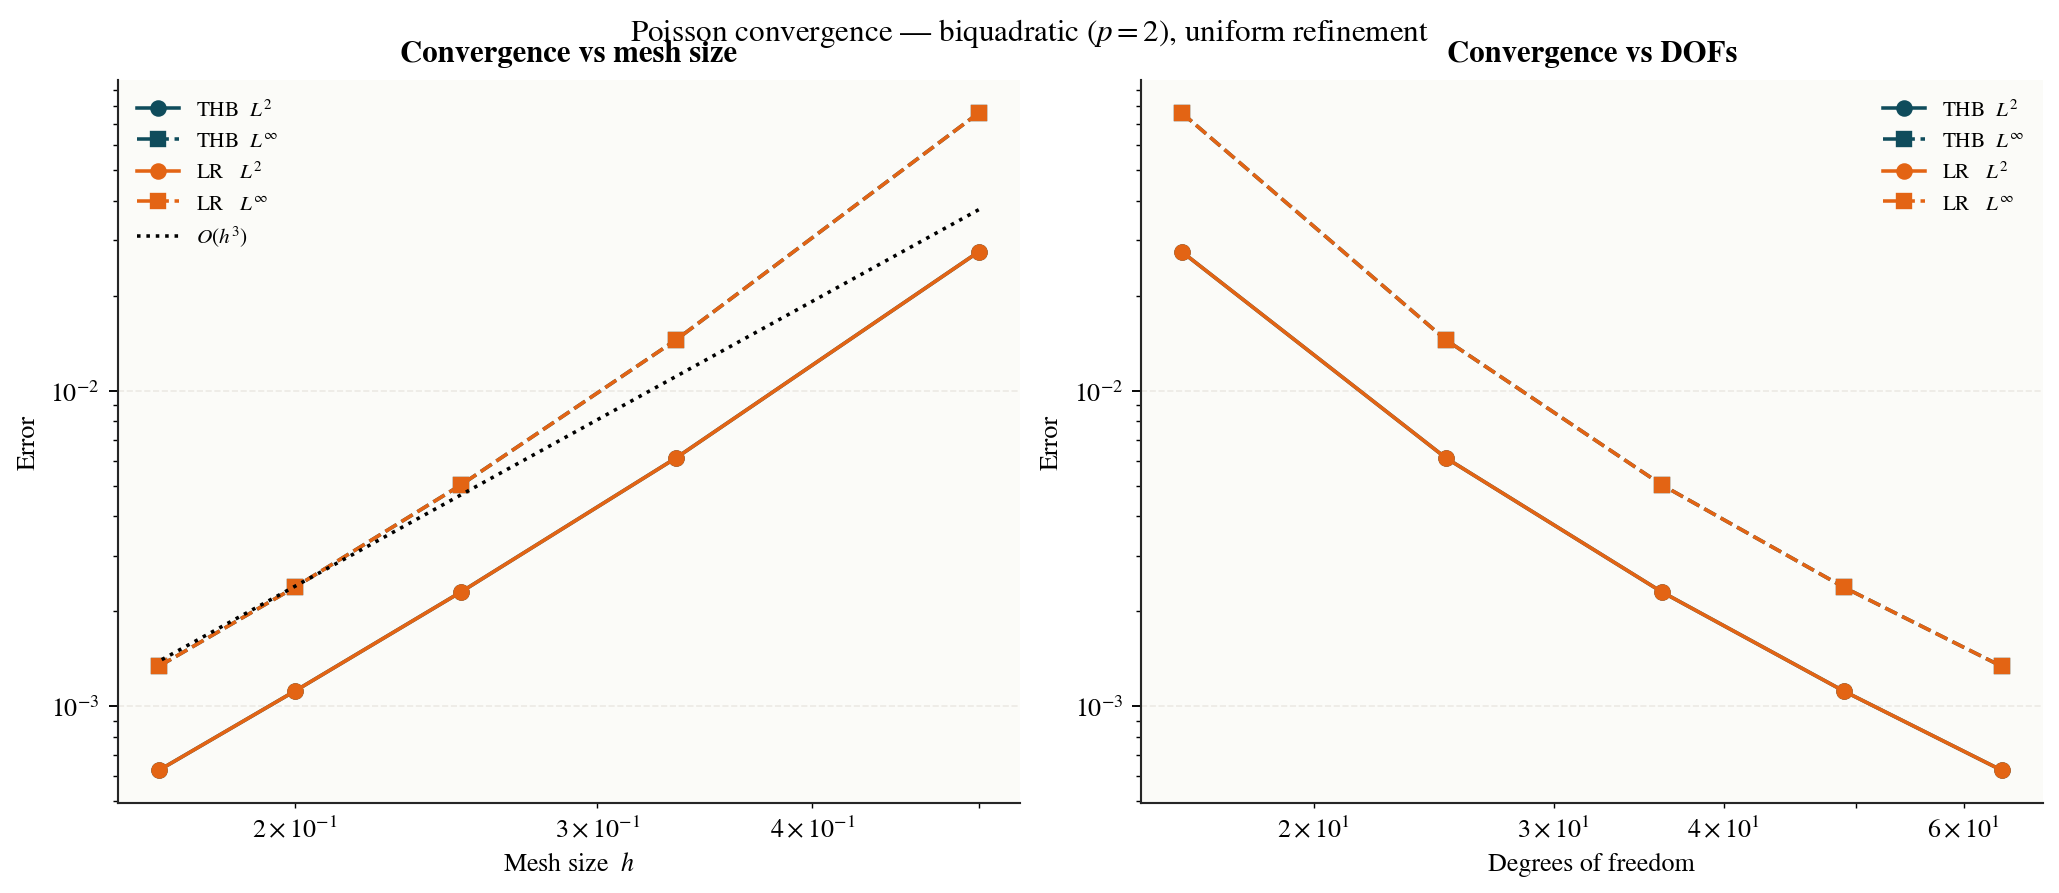

In [21]:
# ── Convergence plots ────────────────────────────────────────────────────────
hs_t    = [r[1] for r in results_thb]
l2_t    = [r[2] for r in results_thb]
linf_t  = [r[3] for r in results_thb]
hs_l    = [r[1] for r in results_lr]
l2_l    = [r[2] for r in results_lr]
linf_l  = [r[3] for r in results_lr]
ndofs_t = [r[0] for r in results_thb]
ndofs_l = [r[0] for r in results_lr]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Left: error vs mesh size h
ax = axes[0]
ax.loglog(hs_t, l2_t,    'o-',  color=LINE_COLORS[0], label='THB  $L^2$')
ax.loglog(hs_t, linf_t,  's--', color=LINE_COLORS[0], label='THB  $L^\\infty$')
ax.loglog(hs_l, l2_l,    'o-',  color=LINE_COLORS[1], label='LR   $L^2$')
ax.loglog(hs_l, linf_l,  's--', color=LINE_COLORS[1], label='LR   $L^\\infty$')
h_ref = np.array([hs_t[0], hs_t[-1]])
ax.loglog(h_ref, 0.3 * h_ref**3, 'k:', lw=1.5, label='$O(h^3)$')
style_axes(ax, xlabel='Mesh size  $h$', ylabel='Error',
           title='Convergence vs mesh size')
ax.legend()

# Right: error vs DOFs
ax = axes[1]
ax.loglog(ndofs_t, l2_t,    'o-',  color=LINE_COLORS[0], label='THB  $L^2$')
ax.loglog(ndofs_t, linf_t,  's--', color=LINE_COLORS[0], label='THB  $L^\\infty$')
ax.loglog(ndofs_l, l2_l,    'o-',  color=LINE_COLORS[1], label='LR   $L^2$')
ax.loglog(ndofs_l, linf_l,  's--', color=LINE_COLORS[1], label='LR   $L^\\infty$')
style_axes(ax, xlabel='Degrees of freedom', ylabel='Error',
           title='Convergence vs DOFs')
ax.legend()

fig.suptitle('Poisson convergence — biquadratic ($p=2$), uniform refinement', y=1.02)

# Empirical convergence rates
def rate(errs, hs):
    return np.polyfit(np.log(hs), np.log(errs), 1)[0]

print(f'Empirical L²  rate — THB: {rate(l2_t,   hs_t):.2f}   LR: {rate(l2_l,   hs_l):.2f}')
print(f'Empirical L∞  rate — THB: {rate(linf_t, hs_t):.2f}   LR: {rate(linf_l, hs_l):.2f}')
print('Expected: ~3.0 for biquadratic splines')

---
## 6. Summary

| Property | THB-splines | LR B-splines |
|----------|-------------|-------------|
| **Refinement mechanism** | Hierarchical levels: coarse functions deactivated, fine added | Overloading: only functions spanning the new mesh line are split |
| **Partition of unity** | Guaranteed by truncation operator | Guaranteed by correct Boehm split coefficients |
| **Linear independence** | Always holds (by construction) | Requires LLI check after each insertion |
| **Mesh structure** | Cartesian grid per level | T-mesh with T-junctions |
| **DOF overhead** | Some coarse functions survive near refined regions | Minimal: only overloaded functions are split |
| **Boundary identification** | Via Greville abscissae (per level) | Via Greville abscissae |
| **Convergence rate** | Optimal $O(h^{p+1})$ | Optimal $O(h^{p+1})$ |

**Note:** HB-splines are implemented here in 1-D only (see Section 6).
The 1-D benchmark is $-u'' = f$ on $[0,1]$, the natural restriction of the 2-D Poisson problem.

All three methods deliver the **same optimal convergence rate** for the Poisson problem.
The main practical differences are in the refinement strategy and the bookkeeping
of active functions.


---
## 6. HB-splines: 1-D benchmark

HB-splines are implemented here in **one spatial dimension**.  We solve the
natural 1-D restriction of the benchmark Poisson problem:

$$-u'' = \pi^2 \sin(\pi x) \quad \text{on }[0,1], \qquad u(0) = u(1) = 0$$

with exact solution $u(x) = \sin(\pi x)$.

We compare:
- **Uniform refinement** (repeated dyadic mesh halving)
- **Adaptive refinement** (full AFEM loop with Dörfler marking and residual estimator)

on the same convergence axis used in Section 5, so the HB-spline rates can be
directly compared against the 2-D THB/LR results.


In [ ]:
# ── HB: smooth 1-D solve on a uniform space ──────────────────────────────────
prob_hb = smooth_diffusion()   # -u'' = π²sin(πx),  u(0)=u(1)=0

knots_hb = [0,0,0, 0.125,0.25,0.375,0.5,0.625,0.75,0.875, 1,1,1]
hspace_hb = HBsplineSpace(knots_hb, degree=2)
c_hb, A_hb1d, F_hb = hb_solve(hspace_hb, prob_hb.f, prob_hb.u0, prob_hb.uL,
                                prob_hb.m, prob_hb.b)

x_1d   = np.linspace(0, 1, 300)
u_h_hb = hspace_hb.eval_solution(x_1d, c_hb)
u_ex1d = prob_hb.u_ex(x_1d)
err_hb = np.abs(u_h_hb - u_ex1d)

L2_hb   = np.sqrt(np.trapezoid((u_h_hb - u_ex1d)**2, x_1d))
Linf_hb = err_hb.max()

print(f'HB-splines (1-D):  DOFs={hspace_hb.nfuncs}   '
      f'L²={L2_hb:.4e}   L∞={Linf_hb:.4e}')

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.0), constrained_layout=True)

ax = axes[0]
ax.plot(x_1d, u_ex1d, lw=2.0, color=LINE_COLORS[0], label='Exact $u$')
ax.plot(x_1d, u_h_hb, lw=1.6, color=LINE_COLORS[1], ls='--',
        label=f'HB-FEM $u_h$  (DOFs={hspace_hb.nfuncs})')
style_axes(ax, xlabel='$x$', ylabel='$u(x)$',
           title='1-D Poisson: HB-spline solution')
ax.legend()

ax = axes[1]
ax.semilogy(x_1d, err_hb + 1e-16, lw=1.8, color=LINE_COLORS[2])
style_axes(ax, xlabel='$x$', ylabel='$|u_h - u|$',
           title='Pointwise error (log scale)')


In [ ]:
# ── HB: convergence — uniform vs adaptive ────────────────────────────────────
import warnings

x_cv = np.linspace(0, 1, 500)
u_ex_cv = prob_hb.u_ex(x_cv)

def hb_uniform(n_cells):
    h = 1.0 / (n_cells + 1)
    knots = [0., 0., 0.] + list(np.arange(h, 1.0, h)) + [1., 1., 1.]
    hs = HBsplineSpace(knots, degree=2)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        c, _, _ = hb_solve(hs, prob_hb.f, prob_hb.u0, prob_hb.uL, prob_hb.m, prob_hb.b)
    u_h = hs.eval_solution(x_cv, c)
    return hs.nfuncs, h, np.sqrt(np.trapezoid((u_h - u_ex_cv)**2, x_cv))

def hb_adaptive(max_dofs):
    hs = HBsplineSpace([0, 0, 0, 0.5, 1, 1, 1], degree=2)
    s  = AdaptiveSolverSettings(max_dofs=max_dofs, tol=0.0, theta=0.4,
                                 strategy='dorfler', verbose=False)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        res = adaptive_solve(prob_hb, hs, s)
    u_h = hs.eval_solution(x_cv, res.c_full)
    h   = 1.0 / (hs.sp_lev[-1].dim - 1)
    return hs.nfuncs, h, np.sqrt(np.trapezoid((u_h - u_ex_cv)**2, x_cv))

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    unif_hb  = [hb_uniform(n)  for n in [2, 4, 8, 16, 32, 64]]
    adap_hb  = [hb_adaptive(d) for d in [6, 10, 15, 25, 50, 100]]

ndofs_hu, hs_hu, l2_hu = zip(*unif_hb)
ndofs_ha, hs_ha, l2_ha = zip(*adap_hb)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0), constrained_layout=True)

# — vs h
ax = axes[0]
ax.loglog(hs_hu, l2_hu, 'o-',  lw=1.8, ms=6, color=LINE_COLORS[3],
          label='HB uniform $L^2$')
ax.loglog(hs_ha, l2_ha, 's--', lw=1.8, ms=6, color=LINE_COLORS[4],
          label='HB adaptive $L^2$')
h_ref = np.array([max(hs_hu), min(hs_hu)])
ax.loglog(h_ref, 0.4 * np.array(l2_hu)[0] * (h_ref / hs_hu[0])**3, 'k:', lw=1.4,
          label='$O(h^3)$')
style_axes(ax, xlabel='Mesh size $h$ (finest level)',
           ylabel='$L^2$ error', title='HB-splines 1-D — convergence vs $h$')
ax.legend()

# — vs DOFs
ax = axes[1]
ax.loglog(ndofs_hu, l2_hu, 'o-',  lw=1.8, ms=6, color=LINE_COLORS[3],
          label='HB uniform $L^2$')
ax.loglog(ndofs_ha, l2_ha, 's--', lw=1.8, ms=6, color=LINE_COLORS[4],
          label='HB adaptive $L^2$')
style_axes(ax, xlabel='Degrees of freedom', ylabel='$L^2$ error',
           title='HB-splines 1-D — convergence vs DOFs')
ax.legend()

print('Uniform  DOFs:', list(ndofs_hu))
print('Uniform  L2  :', [f'{e:.2e}' for e in l2_hu])
print('Adaptive DOFs:', list(ndofs_ha))
print('Adaptive L2  :', [f'{e:.2e}' for e in l2_ha])


In [ ]:
# ── Summary table including HB-splines ───────────────────────────────────────
rows = [
    ('Property',               'THB-splines (2-D)', 'LR B-splines (2-D)', 'HB-splines (1-D)'),
    ('DOFs (adaptive mesh)',   str(Tp.nfuncs),       str(Lp.nfuncs),       str(hspace_hb.nfuncs)),
    ('L² error',               f'{L2_thb:.3e}',      f'{L2_lr:.3e}',       f'{L2_hb:.3e}'),
    ('L∞ error',               f'{Linf_thb:.3e}',    f'{Linf_lr:.3e}',     f'{Linf_hb:.3e}'),
    ('Partition of unity',     '✓ (by truncation)',  '✓ (by Boehm split)', '✗ (no truncation)'),
    ('Boundary identification','Greville abscissae', 'Greville abscissae', 'Boundary index'),
    ('Refinement mechanism',   'Hierarchical levels','T-junction lines',   'Hierarchical levels'),
    ('Problem dimension',      '2-D',                '2-D',                '1-D'),
]

col_w = [max(len(r[c]) for r in rows) for c in range(4)]
sep   = '+' + '+'.join('-' * (w + 2) for w in col_w) + '+'
print(sep)
for i, row in enumerate(rows):
    line = '| ' + ' | '.join(cell.ljust(col_w[c]) for c, cell in enumerate(row)) + ' |'
    print(line)
    if i == 0: print(sep)
print(sep)


---
## 7. Summary

| Property | THB-splines | LR B-splines | HB-splines |
|----------|-------------|-------------|-----------|
| **Refinement** | Hierarchical levels | T-junction insertion | Hierarchical levels |
| **Partition of unity** | ✓ guaranteed (truncation) | ✓ guaranteed (Boehm) | ✗ violated after refinement |
| **Linear independence** | Always holds | Requires LLI check | Always holds |
| **Boundary identification** | Greville abscissae | Greville abscissae | Boundary function index |
| **Implemented problem** | 2-D Poisson | 2-D Poisson | 1-D diffusion / advection-diffusion |
| **Convergence rate** | Optimal $O(h^{p+1})$ | Optimal $O(h^{p+1})$ | Optimal $O(h^{p+1})$ |
| **AFEM loop** | — | — | ✓ residual estimator + Dörfler marking |

All three methods deliver the **same optimal convergence rate** for smooth problems.
The main practical differences are:
- **HB vs THB**: HB-splines lose partition of unity; THB-splines fix this at the cost of the truncation operator.
- **THB vs LR**: different refinement strategies (hierarchical levels vs T-junctions), both valid.
